# Option Pricing with Monte Carlo Simulation and the Black-Scholes Model

This notebook prices two options under geometric Brownian motion (GBM) and checks the Monte Carlo estimates against the Black-Scholes closed form:

| Option | Payoff at $T$ | Black-Scholes price |
|---|---|---|
| European call | $\max(S_T-K,\,0)$ | $S_0N(d_1)-Ke^{-rT}N(d_2)$ |
| Binary cash-or-nothing call (pays $K$) | $K\cdot\mathbb{1}_{\{S_T>K\}}$ | $Ke^{-rT}N(d_2)$ |

with $d_1=\dfrac{\ln(S_0/K)+(r+\tfrac12\sigma^2)T}{\sigma\sqrt T}$ and $d_2=d_1-\sigma\sqrt T$.

**Methods compared**
- **Euler-Maruyama** and **Milstein** discretisations of $dS_t=rS_t\,dt+\sigma S_t\,dW_t$
- **Exact (log-normal) simulation** as a zero-bias reference
- **Antithetic variates** for variance reduction

**Structure**
1. Setup and Black-Scholes benchmarks
2. Simulation engine
3. Base-case comparison (equal computational budget)
4. Discretisation error vs number of time steps (common random numbers)
5. Variance reduction
6. Sensitivity to $S_0, K, T, r, \sigma$
7. Findings and references

## 1. Setup and Black-Scholes benchmarks

Base case: $S_0=100$, $K=105$, $r=5\%$, $\sigma=20\%$, $T=1$ year.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

SEED = 42
BASE = dict(S0=100.0, K=105.0, T=1.0, r=0.05, sigma=0.20)

plt.rcParams.update({'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


def bs_d1_d2(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)


def bs_call(S0, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S0, K, T, r, sigma)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_binary_con(S0, K, T, r, sigma):
    # Cash-or-nothing call paying K if S_T > K
    _, d2 = bs_d1_d2(S0, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(d2)


BS = {'European call': bs_call(**BASE), 'Binary CoN': bs_binary_con(**BASE)}
pd.Series(BS, name='Black-Scholes price').to_frame()

,Black-Scholes price
European call,8.021352
Binary CoN,46.201481


## 2. Simulation engine

One step of length $\Delta t$ with Brownian increment $\Delta W=\sqrt{\Delta t}\,Z$, $Z\sim N(0,1)$:

| Scheme | Update | Strong order | Weak order |
|---|---|---|---|
| Euler-Maruyama | $S_{j+1}=S_j\left(1+r\Delta t+\sigma\Delta W\right)$ | 0.5 | 1 |
| Milstein | $S_{j+1}=S_j\left(1+r\Delta t+\sigma\Delta W+\tfrac12\sigma^2(\Delta W^2-\Delta t)\right)$ | 1 | 1 |
| Exact | $S_{j+1}=S_j\exp\!\left((r-\tfrac12\sigma^2)\Delta t+\sigma\Delta W\right)$ | no error | no error |

Euler-Maruyama and Milstein are applied to $S$ itself. The exact update is the closed-form GBM solution, so it has **no discretisation error at any step size**. It is the reference for measuring the bias of the other two schemes.

**Implementation notes**
- Only the current price vector is kept in memory, not the full path matrix. 150,000 paths × 500 steps would otherwise need about 600 MB per run.
- With `antithetic=True`, half the paths use $Z$ and half use $-Z$. The payoff of each pair is averaged, and the standard error is computed from the pair averages. The total number of paths, and therefore the cost, is the same as a plain run, so the two can be compared fairly.
- Every run gets its own seeded `numpy.random.Generator`, so the results do not depend on the order the cells are run in.

In [2]:
def step(S, dW, dt, r, sigma, scheme):
    if scheme == 'euler':
        return S * (1.0 + r * dt + sigma * dW)
    if scheme == 'milstein':
        return S * (1.0 + r * dt + sigma * dW + 0.5 * sigma**2 * (dW**2 - dt))
    if scheme == 'exact':
        return S * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW)
    raise ValueError(scheme)


def simulate_terminal(S0, T, r, sigma, n_steps, n_paths, scheme, antithetic=False, seed=SEED):
    # Returns simulated S_T. With antithetic=True the first half of the array uses Z, the second half -Z.
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    m = n_paths // 2 if antithetic else n_paths
    S = np.full(2 * m if antithetic else m, S0, dtype=float)
    for _ in range(n_steps):
        dW = np.sqrt(dt) * rng.standard_normal(m)
        if antithetic:
            dW = np.concatenate([dW, -dW])
        S = step(S, dW, dt, r, sigma, scheme)
    return S


PAYOFFS = {
    'European call': lambda ST, K: np.maximum(ST - K, 0.0),
    'Binary CoN':    lambda ST, K: K * (ST > K),
}


def mc_price(option, S0, K, T, r, sigma, n_steps=252, n_paths=100_000,
             scheme='milstein', antithetic=False, seed=SEED):
    ST = simulate_terminal(S0, T, r, sigma, n_steps, n_paths, scheme, antithetic, seed)
    disc = np.exp(-r * T) * PAYOFFS[option](ST, K)
    if antithetic:
        m = len(disc) // 2
        disc = 0.5 * (disc[:m] + disc[m:])   # pair averages are i.i.d.
    return disc.mean(), disc.std(ddof=1) / np.sqrt(len(disc))

## 3. Base-case comparison

Every method uses the same budget: **200,000 paths × 252 steps** (daily steps for one year). The columns are:
- `z = (MC − BS) / SE`: how many standard errors the estimate is from the benchmark. $|z|<2$ means the difference can be explained by sampling noise alone.
- `SE vs plain`: the standard error relative to the plain run of the same scheme.

In [3]:
N_PATHS, N_STEPS = 200_000, 252
rows = []
for option in PAYOFFS:
    for scheme in ['euler', 'milstein', 'exact']:
        for anti in [False, True]:
            t0 = time.perf_counter()
            p, se = mc_price(option, **BASE, n_steps=N_STEPS, n_paths=N_PATHS, scheme=scheme, antithetic=anti)
            rows.append({'Option': option, 'Scheme': scheme,
                         'Method': scheme.capitalize() + (' + antithetic' if anti else ''),
                         'MC price': p, 'Std error': se, 'BS price': BS[option],
                         'MC − BS': p - BS[option], 'z': (p - BS[option]) / se,
                         'Time (s)': time.perf_counter() - t0})

df_base = pd.DataFrame(rows)
df_base['SE vs plain'] = df_base['Std error'] / df_base.groupby(['Option', 'Scheme'])['Std error'].transform('first')
df_base.drop(columns='Scheme').round({'z': 2, 'Time (s)': 2, 'SE vs plain': 3})

,Option,Method,MC price,Std error,BS price,MC − BS,z,Time (s),SE vs plain
0,European call,Euler,8.070023,0.029649,8.021352,0.048670,1.640000,0.780000,1.000000
1,European call,Euler + antithetic,8.034121,0.023580,8.021352,0.012769,0.540000,0.580000,0.795000
2,European call,Milstein,8.069551,0.029661,8.021352,0.048199,1.620000,0.860000,1.000000
3,European call,Milstein + antithetic,8.033144,0.023597,8.021352,0.011791,0.500000,0.690000,0.796000
4,European call,Exact,8.071409,0.029668,8.021352,0.050056,1.690000,0.950000,1.000000
5,European call,Exact + antithetic,8.034992,0.023603,8.021352,0.013640,0.580000,0.700000,0.796000
6,Binary CoN,Euler,46.246515,0.111363,46.201481,0.045034,0.400000,0.830000,1.000000
7,Binary CoN,Euler + antithetic,46.188586,0.041624,46.201481,-0.012896,-0.310000,0.560000,0.374000
8,Binary CoN,Milstein,46.234530,0.111361,46.201481,0.033049,0.300000,0.910000,1.000000
9,Binary CoN,Milstein + antithetic,46.164115,0.041748,46.201481,-0.037366,-0.900000,0.750000,0.375000


## 4. Discretisation error vs number of time steps

The earlier version of this analysis re-ran a fresh simulation for each step count and compared it with Black-Scholes. That difference is dominated by Monte Carlo noise (SE ≈ 0.03 for the call), which is far larger than the discretisation bias. So the error curves were mostly random noise.

Here, **common random numbers** isolate the bias instead. One set of fine Brownian increments (256 steps) is generated and summed into coarser grids. Every scheme and every step count is then driven by the *same* Brownian path, and so is the exact solution. On each path we measure:

- **Weak error:** $\;\mathbb{E}[\text{payoff}_{\text{scheme}}]-\mathbb{E}[\text{payoff}_{\text{exact}}]$, the bias in the option price
- **Strong error:** $\;\mathbb{E}\,|S_T^{\text{scheme}}-S_T^{\text{exact}}|$, the pathwise accuracy

Because both terms of each difference share the same random numbers, the noise mostly cancels. This makes a bias of order $10^{-3}$ measurable with a moderate number of paths.

In [4]:
def discretisation_study(S0, K, T, r, sigma, levels=(1, 2, 4, 8, 16, 32, 64, 128, 256),
                         n_paths=200_000, batch=25_000, seed=SEED):
    rng = np.random.default_rng(seed)
    fine = max(levels)
    acc = {(s, n): {'weak_call': [], 'weak_bin': [], 'strong': []} for s in ['euler', 'milstein'] for n in levels}
    disc = np.exp(-r * T)
    for _ in range(n_paths // batch):
        dW_fine = np.sqrt(T / fine) * rng.standard_normal((batch, fine))
        WT = dW_fine.sum(axis=1)
        ST_exact = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * WT)
        pay_c_ex, pay_b_ex = PAYOFFS['European call'](ST_exact, K), PAYOFFS['Binary CoN'](ST_exact, K)
        for n in levels:
            dW = dW_fine.reshape(batch, n, fine // n).sum(axis=2)   # coarse increments, same Brownian path
            dt = T / n
            for s in ['euler', 'milstein']:
                S = np.full(batch, S0)
                for j in range(n):
                    S = step(S, dW[:, j], dt, r, sigma, s)
                a = acc[(s, n)]
                a['weak_call'].append(disc * (PAYOFFS['European call'](S, K) - pay_c_ex))
                a['weak_bin'].append(disc * (PAYOFFS['Binary CoN'](S, K) - pay_b_ex))
                a['strong'].append(np.abs(S - ST_exact))
    out = []
    for (s, n), a in acc.items():
        row = {'Scheme': s.capitalize(), 'Steps': n}
        for k in a:
            x = np.concatenate(a[k])
            row[k] = x.mean()
            row[k + '_se'] = x.std(ddof=1) / np.sqrt(len(x))
        out.append(row)
    return pd.DataFrame(out)


df_disc = discretisation_study(**BASE)
df_disc[['Scheme', 'Steps', 'weak_call', 'weak_call_se', 'weak_bin', 'weak_bin_se', 'strong']]

,Scheme,Steps,weak_call,weak_call_se,weak_bin,weak_bin_se,strong
0,Euler,1,-0.436522,0.005711,3.722494,0.042305,2.038264
1,Euler,2,-0.189660,0.003725,1.918178,0.038044,1.540199
2,Euler,4,-0.083898,0.002558,0.947353,0.032530,1.132424
3,Euler,8,-0.038939,0.001796,0.472428,0.028053,0.819937
4,Euler,16,-0.018723,0.001272,0.246701,0.023576,0.587700
5,Euler,32,-0.010415,0.000902,0.120854,0.019685,0.418061
6,Euler,64,-0.005027,0.000634,0.081401,0.016956,0.295653
7,Euler,128,-0.002755,0.000448,0.046444,0.013974,0.209207
8,Euler,256,-0.001138,0.000317,0.032461,0.011912,0.147996
9,Milstein,1,-0.395624,0.001700,-0.194265,0.009840,0.709250


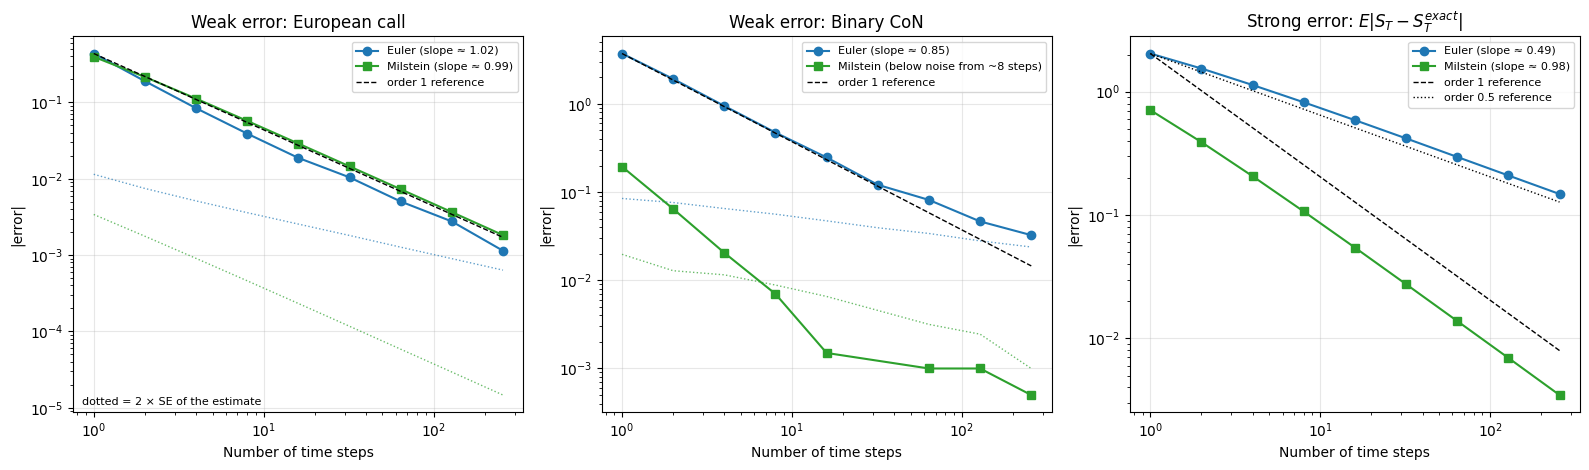

In [5]:
def fitted_order(df, col, scheme, min_steps=2):
    # Log-log slope, using only points where the error is clearly above its own sampling noise (> 2 SE)
    d = df[(df['Scheme'] == scheme) & (df['Steps'] >= min_steps)]
    if col + '_se' in d:
        d = d[d[col].abs() > 2 * d[col + '_se']]
    if len(d) < 3:
        return np.nan
    return -np.polyfit(np.log(d['Steps']), np.log(d[col].abs()), 1)[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
panels = [('weak_call', 'Weak error: European call'), ('weak_bin', 'Weak error: Binary CoN'), ('strong', 'Strong error: $E|S_T - S_T^{exact}|$')]
for ax, (col, title) in zip(axes, panels):
    for s, c, mk in [('Euler', 'tab:blue', 'o'), ('Milstein', 'tab:green', 's')]:
        d = df_disc[(df_disc['Scheme'] == s) & (df_disc[col] != 0)]
        k = fitted_order(df_disc, col, s)
        slope = f'slope ≈ {k:.2f}' if np.isfinite(k) else 'below noise from ~8 steps'
        ax.loglog(d['Steps'], d[col].abs(), color=c, marker=mk, label=f'{s} ({slope})')
        if col != 'strong':
            ax.loglog(d['Steps'], 2 * d[col + '_se'], color=c, ls=':', lw=1, alpha=0.7)
    n = np.array([1, 256.0])
    ref = df_disc.loc[(df_disc['Scheme'] == 'Euler') & (df_disc['Steps'] == 1), col].abs().iloc[0]
    ax.loglog(n, ref / n, 'k--', lw=1, label='order 1 reference')
    if col == 'strong':
        ax.loglog(n, ref / np.sqrt(n), 'k:', lw=1, label='order 0.5 reference')
    ax.set(title=title, xlabel='Number of time steps', ylabel='|error|')
    ax.legend(fontsize=8)
axes[0].text(0.02, 0.02, 'dotted = 2 × SE of the estimate', transform=axes[0].transAxes, fontsize=8)
plt.tight_layout()
plt.savefig('discretisation_error.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Variance reduction from antithetic variates

The paths are evaluated with the exact scheme, so the numbers reflect sampling error only. **Variance reduction factor** = variance per path of plain MC ÷ variance per path of antithetic MC, at the same total number of paths. A factor of 2 means antithetic sampling needs half as many paths for the same standard error.

In [6]:
rows = []
for option in PAYOFFS:
    _, se_plain = mc_price(option, **BASE, n_steps=1, n_paths=N_PATHS, scheme='exact')
    _, se_anti = mc_price(option, **BASE, n_steps=1, n_paths=N_PATHS, scheme='exact', antithetic=True)
    rows.append({'Option': option, 'SE plain': se_plain, 'SE antithetic': se_anti,
                 'SE reduction': 1 - se_anti / se_plain, 'Variance reduction factor': (se_plain / se_anti) ** 2})
df_vr = pd.DataFrame(rows)
df_vr.round(4)

,Option,SE plain,SE antithetic,SE reduction,Variance reduction factor
0,European call,0.029700,0.023600,0.205200,1.583000
1,Binary CoN,0.111300,0.042000,0.623000,7.034200


## 6. Sensitivity to market parameters

Each parameter is varied with the others held at the base case. The Monte Carlo estimates use **Milstein + antithetic, 252 steps, 100,000 paths**. The right-hand column shows MC − BS with a ±2 SE band. If the band covers zero at every point, the Monte Carlo price agrees with the closed form across the whole range.

In [7]:
GRID = {
    'S0':    np.linspace(80, 120, 9),
    'K':     np.linspace(90, 120, 7),
    'T':     np.array([0.1, 0.25, 0.5, 1.0, 1.5, 2.0]),
    'r':     np.array([0.01, 0.02, 0.05, 0.075, 0.10]),
    'sigma': np.array([0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]),
}
BS_FUNC = {'European call': bs_call, 'Binary CoN': bs_binary_con}

rows = []
for param, values in GRID.items():
    for v in values:
        p = {**BASE, param: v}
        for option in PAYOFFS:
            mc, se = mc_price(option, **p, n_steps=252, n_paths=100_000, scheme='milstein', antithetic=True)
            rows.append({'Parameter': param, 'Value': v, 'Option': option,
                         'BS': BS_FUNC[option](**p), 'MC': mc, 'SE': se})
df_sens = pd.DataFrame(rows)
df_sens['MC − BS'] = df_sens['MC'] - df_sens['BS']
df_sens['|z|'] = (df_sens['MC − BS'] / df_sens['SE']).abs()
print(f"Points outside ±2 SE: {(df_sens['|z|'] > 2).sum()} of {len(df_sens)}  (about 5% expected by chance)")
df_sens.pivot_table(index=['Parameter', 'Value'], columns='Option', values=['BS', 'MC']).round(4)

Points outside ±2 SE: 0 of 68  (about 5% expected by chance)


BS                       MC              
Option               Binary CoN European call Binary CoN European call
Parameter Value                                                       
K         90.000000   64.270900     16.699400  64.285000     16.714900
          95.000000   59.443300     13.346500  59.442400     13.362800
          100.000000  53.232500     10.450600  53.160400     10.465700
          105.000000  46.201500      8.021400  46.208100      8.036800
          110.000000  38.924700      6.040100  38.858400      6.055700
          115.000000  31.895000      4.466600  31.952100      4.482000
          120.000000  25.471700      3.247500  25.569000      3.261800
S0        80.000000   11.306600      1.199500  11.251400      1.210000
          85.000000   18.210300      2.183300  18.271900      2.193500
          90.000000   26.705800      3.621300  26.688700      3.634800
          95.000000   36.257400      5.563300  36.192200      5.578400
          100.000000  46.201500      8.021400  46.208100      8.036800
          105.000000  55.894100     10.973100  55.818400     10.989000
          110.000000  64.820700     14.370300  64.882500     14.388200
          115.000000  72.648400     18.149800  72.641100     18.167200
          120.000000  79.226400     22.243100  79.149200     22.260000
T         0.100000    24.502900      0.935400  24.561300      0.939400
          0.250000    35.239900      2.477900  35.277300      2.485400
          0.500000    41.534300      4.581700  41.506800      4.591900
          1.000000    46.201500      8.021400  46.208100      8.036800
          1.500000    48.105200     10.969800  48.126000     10.989700
          2.000000    49.005800     13.639600  48.948100     13.662400
r         0.010000    39.960200      6.297300  39.910500      6.314000
          0.020000    41.542400      6.704800  41.514200      6.721000
          0.050000    46.201500      8.021400  46.208100      8.036800
          0.075000    49.913000      9.223200  49.853100      9.237900
          0.100000    53.394700     10.515100  53.327000     10.527700
sigma     0.050000    49.907500      2.054300  49.899600      2.057200
          0.100000    48.429700      4.046100  48.495300      4.052500
          0.150000    47.274500      6.035600  47.271800      6.046100
          0.200000    46.201500      8.021400  46.208100      8.036800
          0.300000    44.143900     11.976900  44.230500     12.004200
          0.400000    42.141300     15.902900  42.101000     15.945600
          0.500000    40.174300     19.789800  40.156400     19.853500

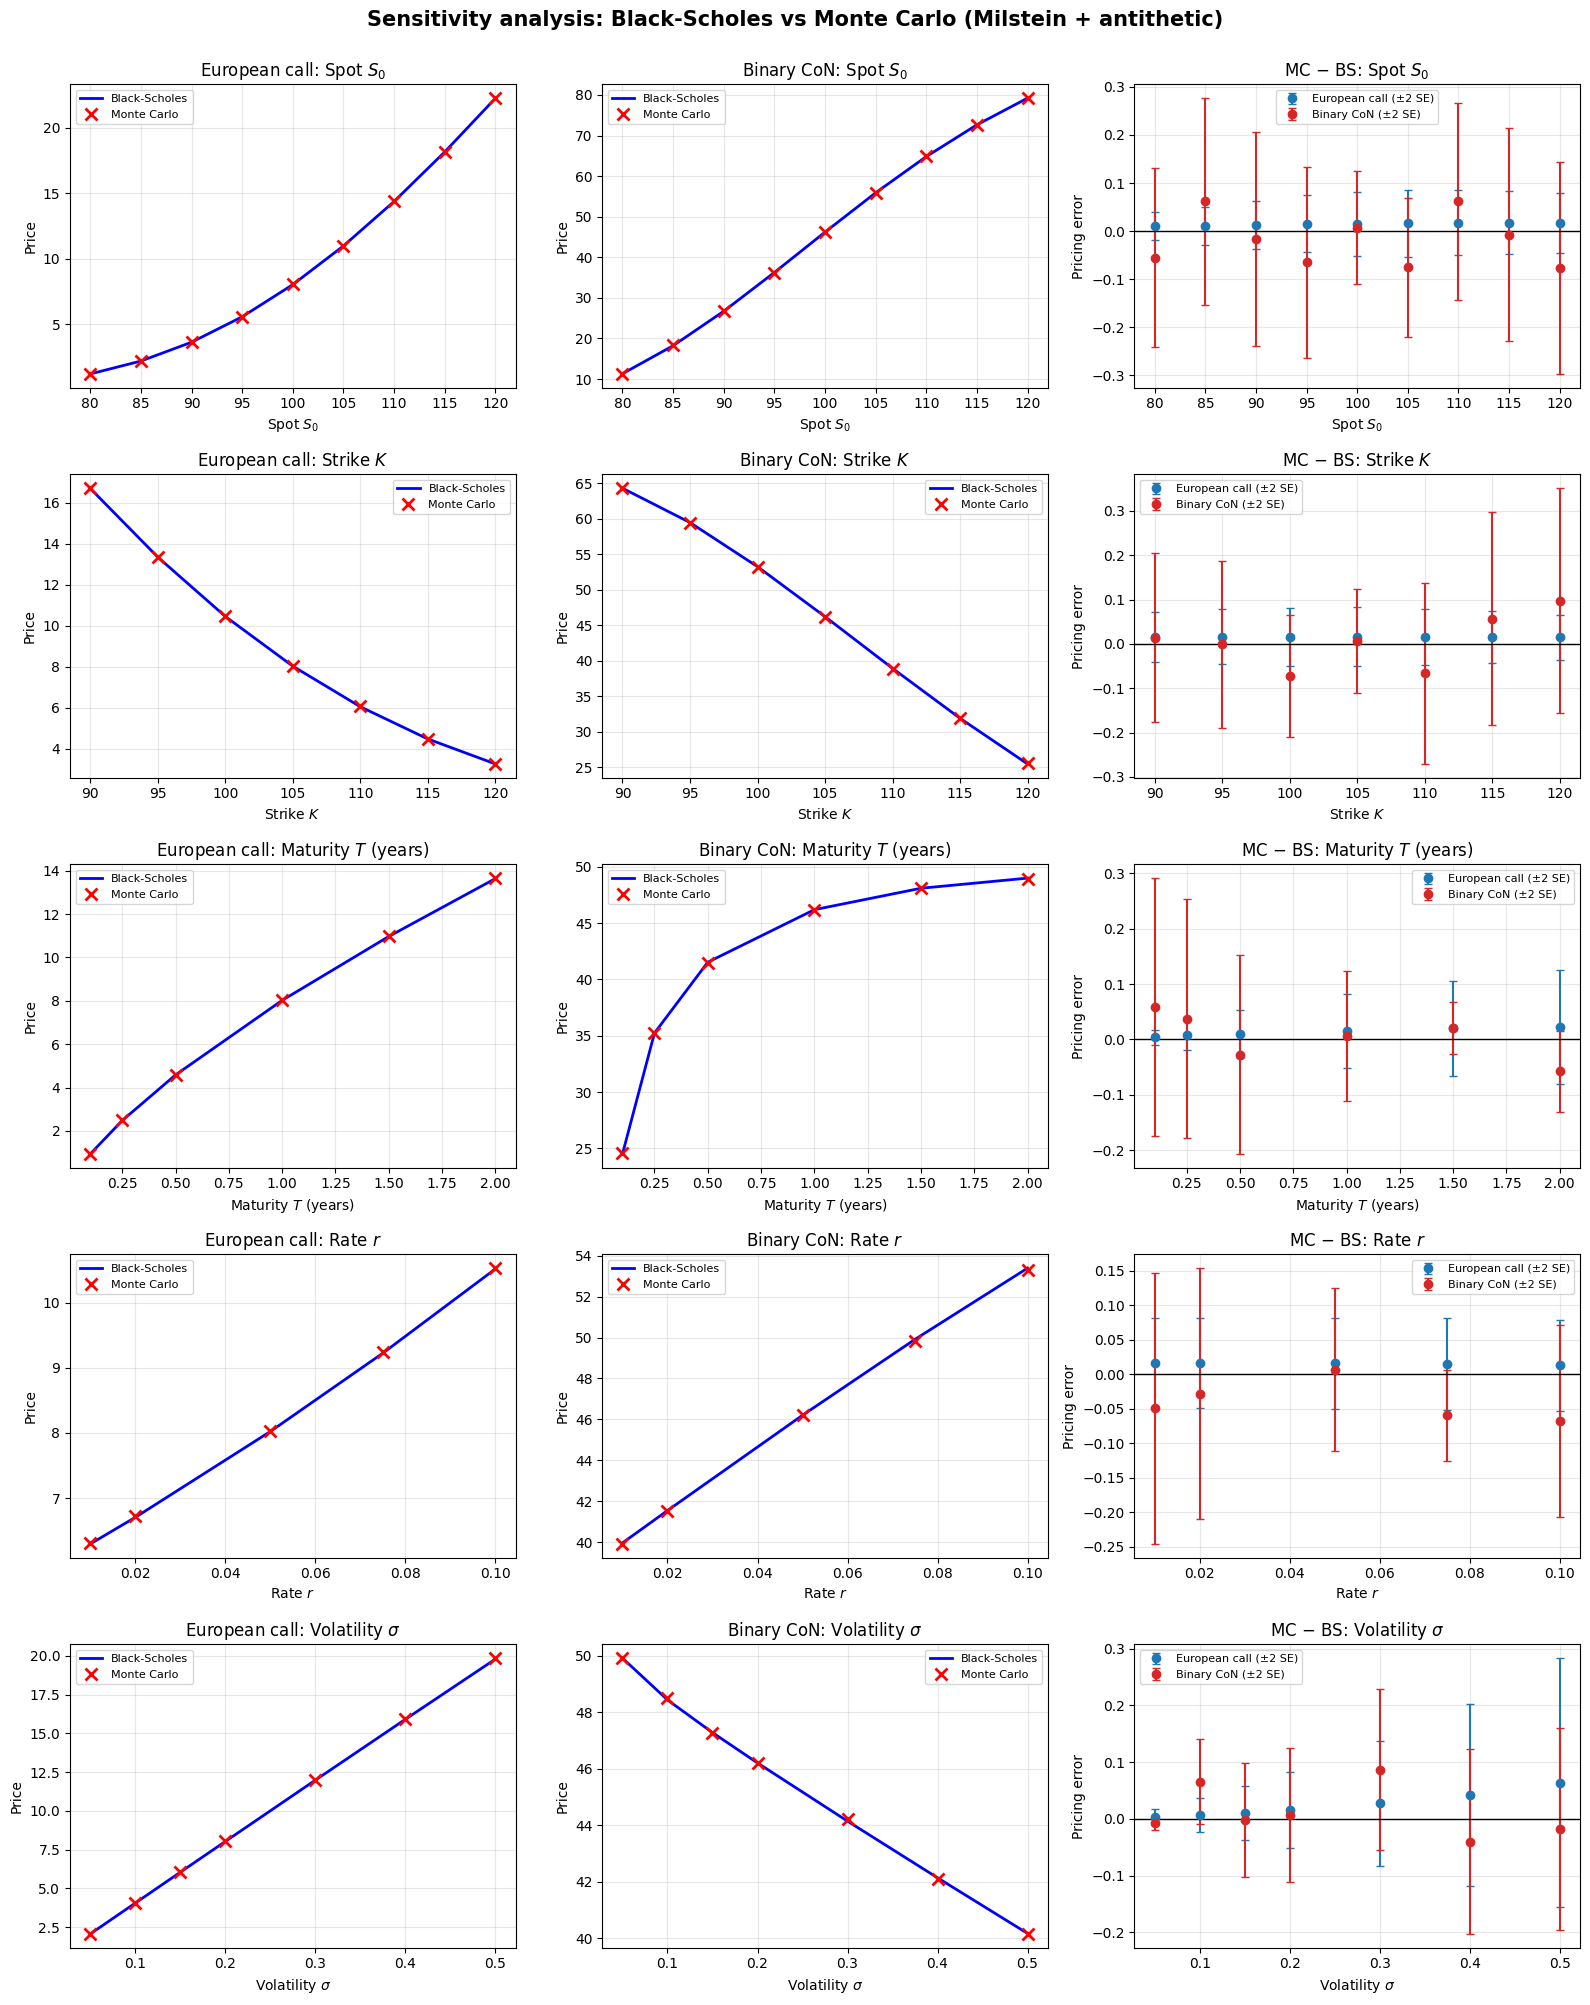

In [8]:
LABELS = {'S0': 'Spot $S_0$', 'K': 'Strike $K$', 'T': 'Maturity $T$ (years)', 'r': 'Rate $r$', 'sigma': r'Volatility $\sigma$'}
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
for i, param in enumerate(GRID):
    for j, option in enumerate(PAYOFFS):
        d = df_sens[(df_sens['Parameter'] == param) & (df_sens['Option'] == option)]
        ax = axes[i, j]
        ax.plot(d['Value'], d['BS'], 'b-', lw=2, label='Black-Scholes')
        ax.plot(d['Value'], d['MC'], 'rx', ms=8, mew=2, label='Monte Carlo')
        ax.set(title=f'{option}: {LABELS[param]}', xlabel=LABELS[param], ylabel='Price')
        ax.legend(fontsize=8)
    ax = axes[i, 2]
    for option, c in [('European call', 'tab:blue'), ('Binary CoN', 'tab:red')]:
        d = df_sens[(df_sens['Parameter'] == param) & (df_sens['Option'] == option)]
        ax.errorbar(d['Value'], d['MC − BS'], yerr=2 * d['SE'], fmt='o', color=c, capsize=3, label=f'{option} (±2 SE)')
    ax.axhline(0, color='k', lw=1)
    ax.set(title=f'MC − BS: {LABELS[param]}', xlabel=LABELS[param], ylabel='Pricing error')
    ax.legend(fontsize=8)
fig.suptitle('Sensitivity analysis: Black-Scholes vs Monte Carlo (Milstein + antithetic)', fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Findings

**1. Every method agrees with Black-Scholes within sampling error.** In the base case, all 12 estimates are within 2 standard errors of the closed form ($|z|<2$). The same holds for all 68 points of the sensitivity analysis. With 252 steps, the choice of scheme makes no visible difference to the price. The Euler, Milstein and exact estimates differ by less than 0.002 for the call, while the standard error is about 0.03.

**2. The discretisation bias is small, and it behaves as theory predicts.** Common random numbers make the bias measurable (Section 4):

| | Euler-Maruyama | Milstein |
|---|---|---|
| Strong order (fitted) | ≈ 0.5 | ≈ 1.0 |
| Weak order, European call (fitted) | ≈ 1.0 | ≈ 1.0 |
| Weak error, call, 252 steps | ≈ −0.001 | ≈ −0.002 |
| Weak error, binary, 256 steps | ≈ +0.03 | below noise |

- **Strong error:** Milstein converges pathwise at order 1, against Euler's order 0.5. At 256 steps its pathwise error is about 40× smaller.
- **Weak error for the call:** both schemes have weak order 1. Milstein gives *no* price improvement for the European call, and its bias is in fact slightly larger in this case.
- **Weak error for the binary:** Milstein is much better. The digital payoff depends on which side of $K$ the path ends, and that is a pathwise property. Euler still has a bias of about 0.03 at 256 steps, which is comparable to the Monte Carlo standard error.

**3. Sampling error, not discretisation, is the binding constraint.** At 252 steps the bias is ≤ 0.002 for the call, while the standard error with 200,000 paths is about 0.024–0.030. To reach SE = 0.01 with antithetic sampling you need roughly **1.1 million paths for the call and 3.5 million for the binary** (table below). Adding time steps beyond ~50 does not help the price. More paths or better variance reduction does.

**4. Antithetic variates help, but by very different amounts.** At equal cost, antithetic sampling cuts the standard error by **about 20% for the call** (variance reduction factor ≈ 1.6) and by **about 62% for the binary** (factor ≈ 7). The binary gains more because its payoff is close to monotone in $Z$ near the money, so the $Z$ and $-Z$ payoffs are strongly negatively correlated.

**5. Sensitivities match the Black-Scholes Greeks.**
- The call value is increasing and **convex** in $S_0$ (not linear), decreasing in $K$, and increasing in $T$, $r$ and $\sigma$.
- The binary value rises with $S_0$ and $r$ and falls with $K$.
- In this set-up ($S_0<K$, and it pays $K$) the binary value **falls** as $\sigma$ rises: from 49.9 at $\sigma=5\%$ to 40.2 at $\sigma=50\%$. The sign of a digital's vega depends on moneyness. The binary price also rises with $T$ here, because the positive drift $r$ pushes the risk-neutral probability $N(d_2)$ up faster than discounting lowers it.
- The same seed is used at every grid point (common random numbers). So the MC − BS errors are correlated across points (for the call they all have the same sign). This makes the curves smooth, but it does not mean the estimates are biased.

**6. Practical takeaways**
- Under GBM, simulate $S_T$ exactly. Time stepping is only needed for path-dependent payoffs or models without a closed-form solution.
- When a discretisation scheme is needed, use Milstein for discontinuous payoffs (digitals, barriers). For smooth payoffs, Euler's weak accuracy is equivalent.
- Always report the standard error, and choose the number of paths from a target SE rather than a fixed rule of thumb.

In [9]:
# Paths needed for a target standard error, from the per-path standard deviation in Section 5
rows = []
for _, v in df_vr.iterrows():
    sd_anti = v['SE antithetic'] * np.sqrt(N_PATHS)
    for target in [0.01, 0.05]:
        rows.append({'Option': v['Option'], 'Target SE': target,
                     'Paths (antithetic)': int(np.ceil((sd_anti / target) ** 2 / 2) * 2)})
pd.DataFrame(rows).pivot(index='Option', columns='Target SE', values='Paths (antithetic)')

Target SE,0.010000,0.050000
Option,,
Binary CoN,3524310,140974
European call,1115354,44616


## References

- Black, F. & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3), 637–654.
- Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science*, 4(1), 141–183.
- Boyle, P. P. (1977). Options: A Monte Carlo approach. *Journal of Financial Economics*, 4(3), 323–338.
- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*. Springer.
- Kloeden, P. E. & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.
- Rubinstein, M. & Reiner, E. (1991). Unscrambling the binary code. *Risk*, 4(9), 75–83.